# 📱 Cell Price Prediction

<img src="cell Phone Predication.jpg" alt="Mobile Price Prediction" width="600">
<center>
    
### By *Likhitha Jajam(PTID-CDS-JUL-25-2964)*

</center>

<center>

### Task 1
</center>

In [1]:
! pip install pgeocode
!pip install 'numpy>=1.16.5,<1.23.0'
import pgeocode
import itertools 
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import plot
import plotly.figure_factory as ff
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV

The system cannot find the file specified.


In [2]:
df = pd.DataFrame(pd.read_csv('datasets_11167_15520_train.csv'))
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [3]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
#Fortunately there's not any duplicates or missing values

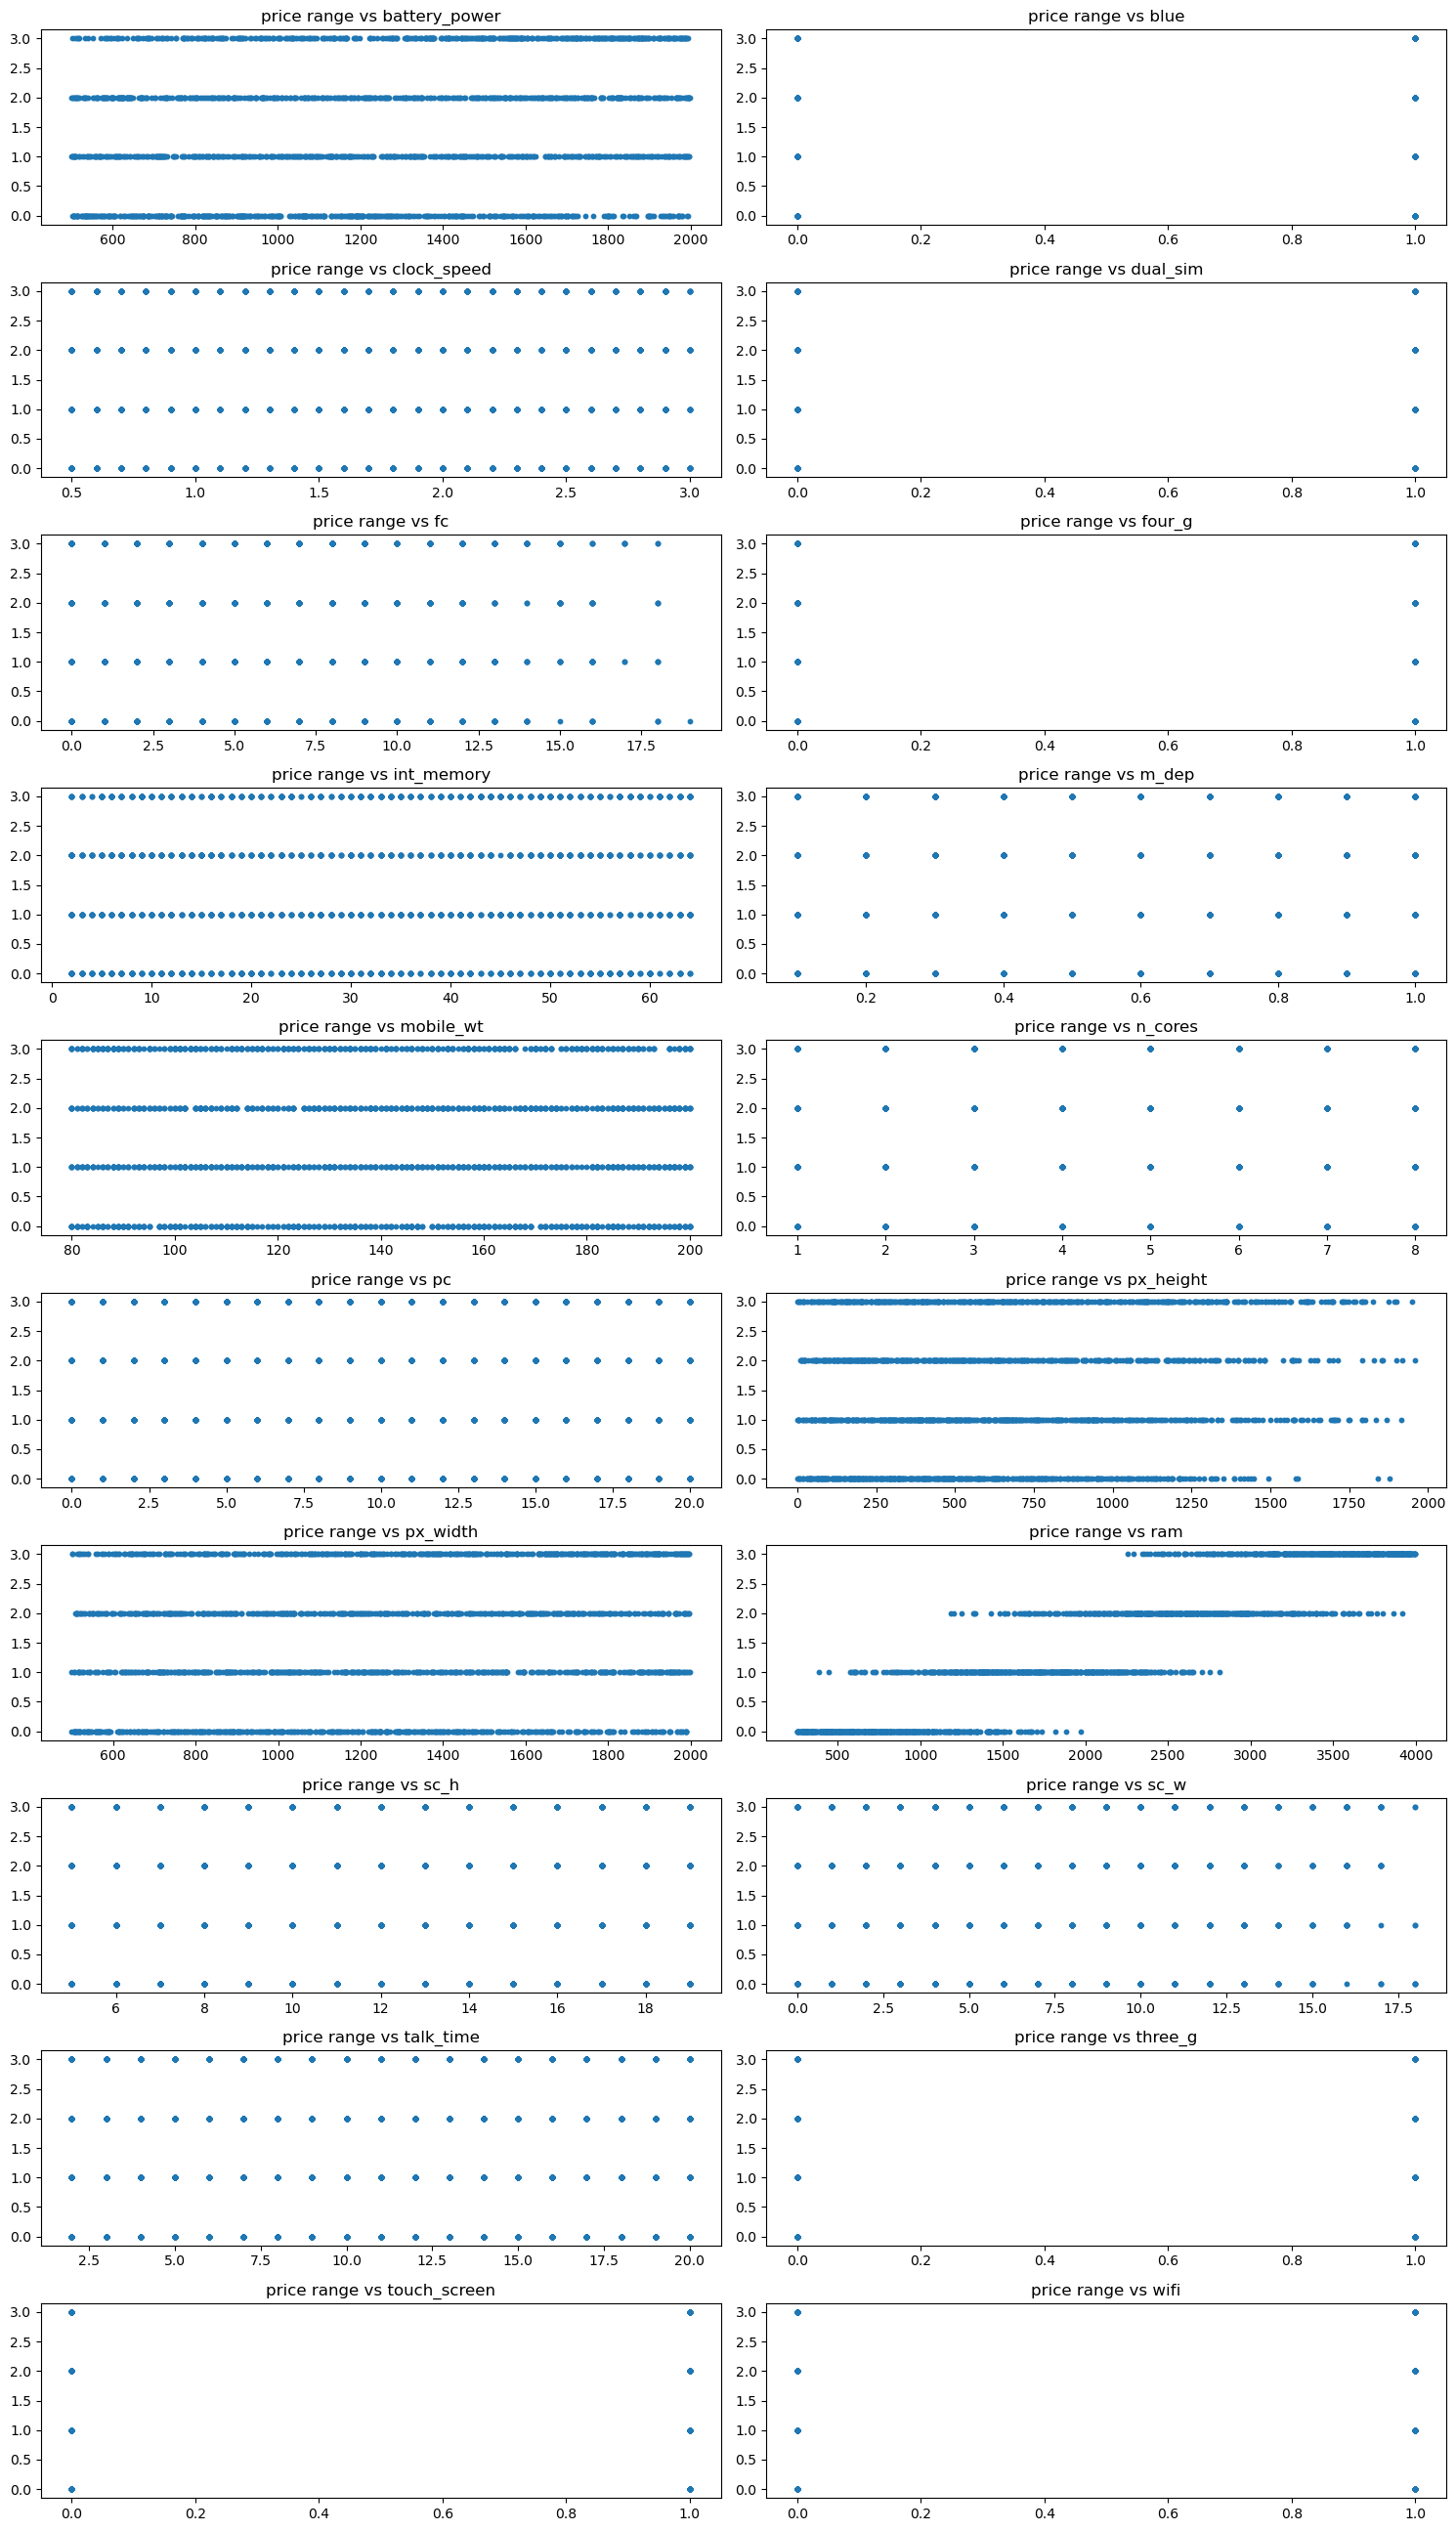

In [8]:
df2 = df.drop(columns=['price_range'])
fig, axs = plt.subplots(10, 2, figsize=(15, 26))
j = 0
for i in range(len(df2.columns)):
    axs[i//2, j].scatter(df2[df2.columns[i]], df['price_range'], s=10)
    axs[i//2, j].set_title(f"price range vs {df2.columns[i]}")
    j = 1 if j == 0 else 0
    fig.tight_layout()

In [9]:
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
# Create subplots with 2 rows and 3 columns
fig = make_subplots(rows=3, cols=3, specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
                                           [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}],
                                           [{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]])

annotations = []
x_coordinates = [0.12, 0.5, 0.92] # change the x-coordinate for each row
y_coordinates = [1.03, 0.65, 0.27] # change the y-coordinate for each row
colors = ['#F15189', '#B0E0E6', '#30D06A', '#FC9631', '#D1D630']
features = ['wifi', 'four_g', 'three_g', 'blue', 'dual_sim', 'n_cores', 'm_dep', 'talk_time', 'price_range']
# Add pie charts to each subplot
for i in range(len(features)):
    fig.add_trace(go.Pie(labels=df[features[i]].value_counts().index.tolist(), values=np.asarray(df[features[i]].value_counts()), hole=.3, marker=dict(colors=colors), name=features[i]), row=(i//3)+1, col=(i%3)+1)
    annotations.append(dict(text=f'{features[i]}',
                            x=x_coordinates[i%3],
                            y=y_coordinates[i//3],
                            font=dict(size=18),
                            showarrow=False))
        
# Update layout
fig.update_layout(height=1200, width=1000, title={'text': "Features", 'font': {'size': 30}, 'x': 0.5, 'y':0.98}, annotations=annotations)
fig.update_layout(showlegend=False)
# Show figure
fig.show()

In [10]:
#As we can see, the labels (price range) are equally distributed and we have exactly 25% of each
#Also other features are showing the same behavior except for "3G" which is mostly 1 rather than 0

C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\1356844159.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\1356844159.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\1356844159.py:4: UserWarning:


The palette list has fewer values (7) than needed (26) and will cycle, which may produce an uninterpretable plot.

C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\1356844159.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\DELL\AppData\Local\Temp\ipykernel_9304\1356844

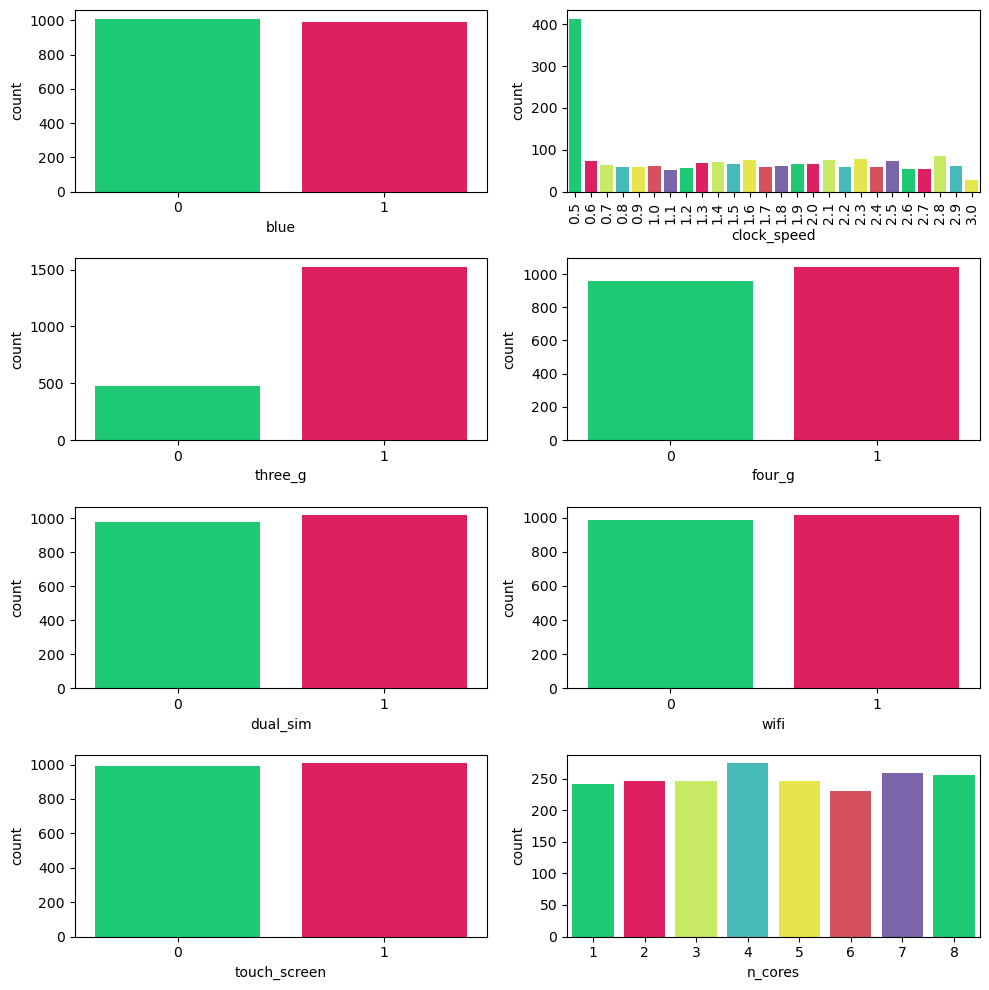

In [11]:
colors = ['#00e673', '#ff0055', '#d2ff4d', '#33cccc', '#FFFF33', '#EC3B4E', '#7559B6']
fig, ax = plt.subplots(4,2, figsize=(10,10))
sns.countplot(x='blue', data=df, ax=ax[0,0], palette=colors[:len(df['blue'].unique())])
sns.countplot(x='clock_speed', data=df, ax=ax[0,1], palette=colors[:len(df['clock_speed'].unique())])
sns.countplot(x='three_g', data=df, ax=ax[1,0], palette=colors[:len(df['three_g'].unique())])
sns.countplot(x='four_g', data=df, ax=ax[1,1], palette=colors[:len(df['four_g'].unique())])
sns.countplot(x='dual_sim', data=df, ax=ax[2,0], palette=colors[:len(df['dual_sim'].unique())])
sns.countplot(x='wifi', data=df, ax=ax[2,1], palette=colors[:len(df['wifi'].unique())])
sns.countplot(x='touch_screen', data=df, ax=ax[3,0], palette=colors[:len(df['touch_screen'].unique())])
sns.countplot(x='n_cores', data=df, ax=ax[3,1], palette=colors[:len(df['n_cores'].unique())])

ax[0,1].tick_params(axis='x', labelsize=10)
ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=90)

fig.tight_layout()

In [12]:
fig = make_subplots(rows=2, cols=2, subplot_titles=('talk_time', 'battery_power', 'px_width', 'm_dep'))

for i in range(4):
    fig.add_trace(go.Box(y=df[df['price_range'] == i]['talk_time'], name=f'{i}', marker_color='purple'), row=1, col=1)
    fig.add_trace(go.Box(y=df[df['price_range'] == i]['battery_power'], name=f'{i}', marker_color='red'), row=1, col=2)
    fig.add_trace(go.Box(y=df[df['price_range'] == i]['px_width'], name=f'{i}', marker_color='green'), row=2, col=1)
    fig.add_trace(go.Box(y=df[df['price_range'] == i]['m_dep'], name=f'{i}', marker_color='orange'), row=2, col=2)

fig.update_layout(height=800, width=900)
fig.update_traces(showlegend=False)
fig.update_xaxes(title_text="Price Range", row=1, col=1)
fig.update_xaxes(title_text="Price Range", row=1, col=2)
fig.update_xaxes(title_text="Price Range", row=2, col=1)
fig.update_xaxes(title_text="Price Range", row=2, col=2)
fig.show()

In [13]:
fig = px.box(df, y='battery_power', color='price_range')
fig.update_layout(
    height=600,  # set the height in pixels
    width=600    # set the width in pixels
)
fig.show()

In [14]:
fig = px.box(df, y='m_dep', color='price_range')
fig.update_layout(
    height=600,  # set the height in pixels
    width=600    # set the width in pixels
)
fig.show()

In [15]:
fig = px.box(df, y='px_height', color='price_range')
fig.update_layout(
    height=600,  # set the height in pixels
    width=600    # set the width in pixels
)
fig.show()

In [16]:
fig = px.box(df, y='ram', color='price_range')
fig.update_layout(
    height=600,  # set the height in pixels
    width=600    # set the width in pixels
)
fig.show()

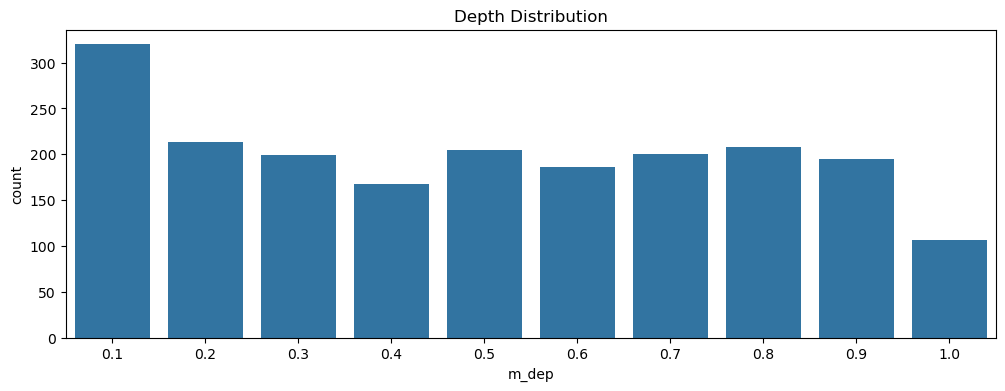

In [17]:
plt.figure(figsize=(12,4))
sns.countplot(x='m_dep', data=df)
plt.xticks(rotation=0)
plt.title('Depth Distribution')
plt.show()

In [18]:
labels = ['px_height', 'px_width']
hist_data = [df[x] for x in labels]
colors = ['#533F44', '#37bA9C']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot(hist_data, labels, show_hist=False, colors=colors)

# Add title
fig.update_layout(title_text='PX')
fig.show()

In [19]:
def Scatter3d(x='ram', y='int_memory', z='price_range', color='price_range'):
    fig = px.scatter_3d(df, x=x, y=y, z=z, color=color, template='gridon', opacity=0.5)
    fig.update_layout(width=700, height=700, title={'text': f"'{z}' vs '{x}' vs '{y}'", 'font': {'size': 24, 'color': 'green'}})
    fig.show()
Scatter3d()

In [20]:
Scatter3d(x='talk_time', y='battery_power')

In [21]:
Scatter3d(x='sc_h', y='sc_w')

In [22]:
Scatter3d(x='px_height', y='px_width')

In [23]:
Scatter3d(x='mobile_wt', y='sc_h')

In [24]:
Scatter3d(x='pc', y='fc')

In [25]:
fig = px.scatter(df, x="sc_w", y="sc_h", size='m_dep', size_max=20)
fig.update_layout(width=700, height=600, title={'text': f"screen height vs width", 'font': {'size': 24, 'color': 'blue'}})
fig.show()

In [26]:
# Create subplots
fig = make_subplots(rows=4, cols=2)

# Define plot traces
traces = []
features = ['wifi', 'four_g', 'three_g', 'blue', 'dual_sim', 'n_cores', 'm_dep', 'talk_time']
for i in range(len(features)):
    traces.append(go.Scatter(y=df['ram'], x=df[features[i]], mode='markers',
                             marker=dict(size=5, opacity=0.2, color=df['price_range']),
                             name=features[i]))
    fig.add_trace(traces[i], row=(i//2)+1, col=(i%2)+1)
    fig.update_xaxes(title_text=features[i], row=(i//2)+1, col=(i%2)+1)
    fig.update_yaxes(title_text='ram', row=(i//2)+1, col=(i%2)+1)

# Update layout
fig.update_layout(height=1400, width=1000, template='ggplot2', showlegend=False)

# Show figure
fig.show()

In [27]:
df[(df['three_g']==0) & (df['four_g']==1)]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range


In [28]:
df[(df['three_g']==0) & (df['wifi']==1)]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
19,682,1,0.5,0,4,0,19,1.0,121,4,...,902,1064,2337,11,1,18,0,1,1,1
22,1949,0,2.6,1,4,0,47,0.3,199,4,...,407,822,1433,11,5,20,0,0,1,1
30,1579,1,0.5,1,0,0,5,0.2,88,7,...,1358,1739,3532,17,11,12,0,0,1,3
45,1514,0,2.9,0,0,0,27,0.2,118,3,...,186,1810,1152,8,3,20,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,555,1,0.5,1,2,0,17,0.2,163,5,...,956,1010,343,19,14,3,0,1,1,0
1966,1583,0,1.2,1,0,0,14,0.2,148,2,...,1171,1673,2498,13,6,8,0,0,1,2
1981,1454,0,2.6,0,8,0,6,0.4,199,3,...,698,1018,1300,10,0,2,0,0,1,1
1983,1262,0,1.8,1,12,0,34,0.1,149,5,...,223,737,3248,13,3,4,0,1,1,2


In [29]:
#There're 749 samples that have 3G but no wifi!

In [30]:
df[(df['three_g']==1) & (df['wifi']==0)]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,1617,1,2.4,0,8,1,36,0.8,85,1,...,743,1426,296,5,3,7,1,0,0,0
1991,1882,0,2.0,0,11,1,44,0.8,113,8,...,4,743,3579,19,8,20,1,1,0,3
1994,858,0,2.2,0,1,0,50,0.1,84,1,...,528,1416,3978,17,16,3,1,1,0,3
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0


In [31]:
df[(df['three_g']==0) & (df['dual_sim']==1)]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
10,769,1,2.9,1,0,0,9,0.1,182,5,...,248,874,3946,5,2,7,0,0,0,3
22,1949,0,2.6,1,4,0,47,0.3,199,4,...,407,822,1433,11,5,20,0,0,1,1
30,1579,1,0.5,1,0,0,5,0.2,88,7,...,1358,1739,3532,17,11,12,0,0,1,3
49,596,0,2.1,1,9,0,64,0.8,111,8,...,885,1854,3238,16,13,10,0,0,0,3
51,1760,0,1.4,1,5,0,63,0.8,127,8,...,1382,1383,2053,19,12,16,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,555,1,0.5,1,2,0,17,0.2,163,5,...,956,1010,343,19,14,3,0,1,1,0
1958,1976,1,2.6,1,6,0,45,1.0,136,4,...,652,1933,2470,11,1,3,0,0,0,3
1966,1583,0,1.2,1,0,0,14,0.2,148,2,...,1171,1673,2498,13,6,8,0,0,1,2
1967,1783,0,2.9,1,2,0,42,0.7,104,6,...,1081,1979,387,14,5,3,0,1,0,1


In [32]:
#There's no cellphone with height less than width (otherwise it would be noise)

In [33]:
df[df['sc_h'] <= df['sc_w']]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range


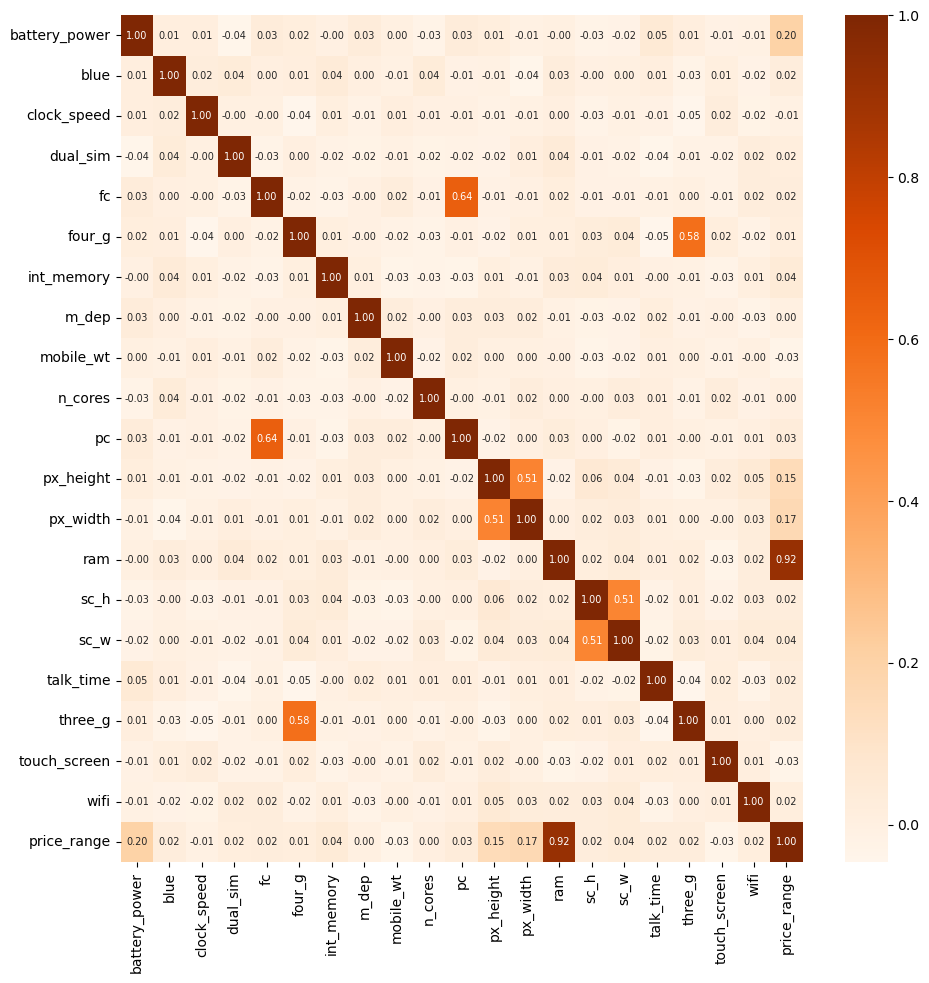

In [34]:
plt.figure(figsize=(11,11))
sns.heatmap(df.corr(), cmap="Oranges", annot=True, fmt='0.2f', annot_kws={'fontsize':7})
plt.show()

<center>

### Task 2

</center>

In [35]:
def plot_confusion_matrix(cm, classes, normalize=False):
    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

dict_characters = {0: 'low cost', 1: 'medium', 2: 'high', 3: 'very high'}

### Creating the Models

In [36]:
df3 = df.copy()

In [37]:
X = df3.drop(columns=['price_range']).values
y = df3['price_range'].values


In [38]:
# as the min of test set might be lower than train set, we can't just normalize the train and then transform it to test, 
# we normalize the whole X and then split
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### Desicion Tree

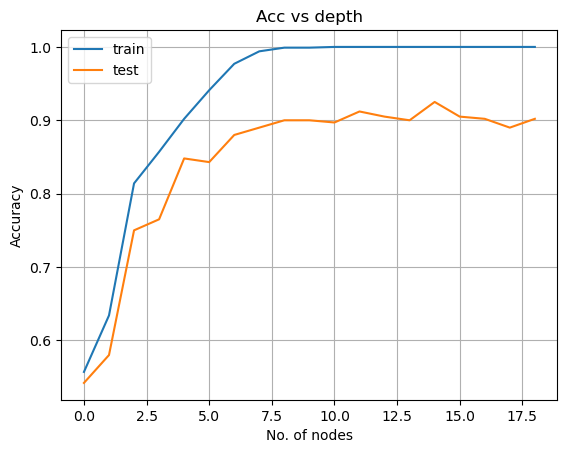

In [39]:
train_list, test_list = [], []
for i in range(1, 20):
    DT_model = RandomForestClassifier(criterion='entropy', max_depth=i)
    DT_model.fit(X_train, y_train)
    train_list.append(round(DT_model.score(X_train, y_train), 3))
    test_list.append(round(DT_model.score(X_test, y_test), 3))
plt.plot(train_list, label='train')
plt.plot(test_list, label='test')
plt.title('Acc vs depth')
plt.ylabel('Accuracy')
plt.xlabel('No. of nodes')
plt.legend()
plt.grid()
plt.show()

In [40]:
train_list, test_list, depth_list, max_features_list = [], [], [], []
for d in range(5, 15):
    for mf in ['sqrt', 'log2', None]:
        DT_model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=0)
        DT_model.fit(X_train, y_train)
        y_pred = DT_model.predict(X_test)
        train_list.append(round(DT_model.score(X_train, y_train), 3))
        test_list.append(round(DT_model.score(X_test, y_test), 3))
        depth_list.append(d)
        max_features_list.append(mf)
output = pd.DataFrame({'train': train_list, 'test': test_list, 'depth': depth_list, 'max_features': max_features_list})

In [41]:
output.style.highlight_max(color = 'lightgreen', axis = 0, subset=['train', 'test'])

,train,test,depth,max_features
0,0.873000,0.848000,5,sqrt
1,0.873000,0.848000,5,log2
2,0.873000,0.848000,5,None
3,0.916000,0.868000,6,sqrt
4,0.916000,0.868000,6,log2
5,0.916000,0.868000,6,None
6,0.956000,0.863000,7,sqrt
7,0.956000,0.863000,7,log2
8,0.956000,0.863000,7,None
9,0.984000,0.887000,8,sqrt


In [42]:
result = cross_val_score(DT_model, X, y, cv=KFold(8))
print(result)
print(np.mean(result))

[0.884 0.868 0.868 0.828 0.824 0.856 0.872 0.86 ]
0.8574999999999999


### Random Forest

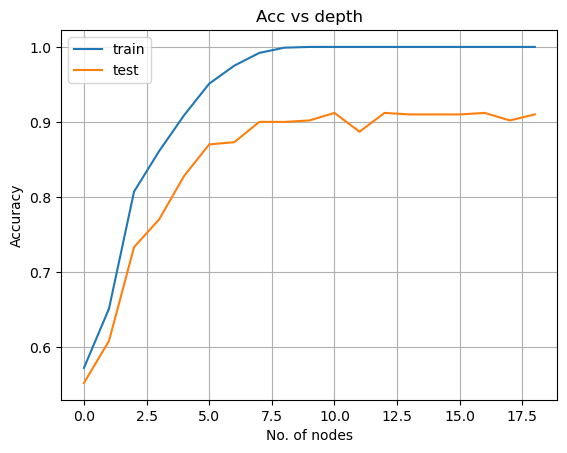

In [43]:
train_list, test_list = [], []
for i in range(1, 20):
    RF_model = RandomForestClassifier(criterion='entropy', max_depth=i, n_estimators=150)
    RF_model.fit(X_train, y_train)
    y_pred = RF_model.predict(X_test)
    train_list.append(round(RF_model.score(X_train, y_train), 3))
    test_list.append(round(RF_model.score(X_test, y_test), 3))
plt.plot(train_list, label='train')
plt.plot(test_list, label='test')
plt.title('Acc vs depth')
plt.ylabel('Accuracy')
plt.xlabel('No. of nodes')
plt.legend()
plt.grid()
plt.show()

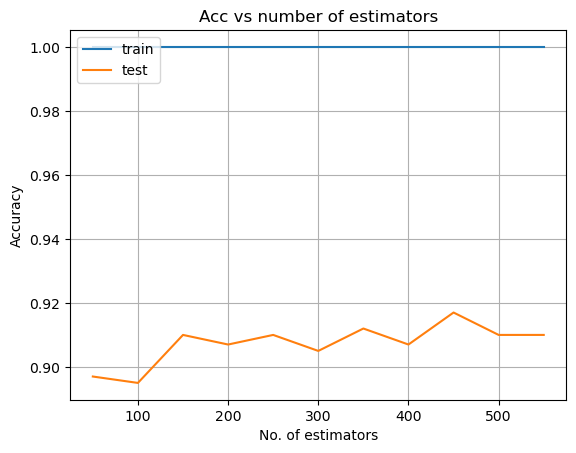

In [44]:
train_list, test_list = [], []
for i in range(50, 600, 50):
    RF_model = RandomForestClassifier(criterion='entropy', max_depth=15, n_estimators=i)
    RF_model.fit(X_train, y_train)
    y_pred = RF_model.predict(X_test)
    train_list.append(round(RF_model.score(X_train, y_train), 3))
    test_list.append(round(RF_model.score(X_test, y_test), 3))
plt.plot(range(50, 600, 50), train_list, label='train')
plt.plot(range(50, 600, 50), test_list, label='test')
plt.title('Acc vs number of estimators')
plt.ylabel('Accuracy')
plt.xlabel('No. of estimators')
plt.legend()
plt.legend(loc='upper left')
plt.grid()
plt.show()

In [ ]:
train_list, test_list, depth_list, estimators_list, max_features_list = [], [], [], [], []
for d in range(8, 15):
    for e in range(50, 600, 50):
        for mf in ['sqrt', 'log2', None]:
            RF_model = RandomForestClassifier(criterion='entropy', max_depth=d, n_estimators=e, max_features=mf, random_state=2)
            RF_model.fit(X_train, y_train)
            train_list.append(round(RF_model.score(X_train, y_train), 3))
            test_list.append(round(RF_model.score(X_test, y_test), 3))
            estimators_list.append(e)
            depth_list.append(d)
            max_features_list.append(mf)
output = pd.DataFrame({'train': train_list, 'test': test_list, 'depth': depth_list, 'estimators': estimators_list, 'max_features': max_features_list})

In [46]:
output.style.highlight_max(color = 'lightgreen', axis = 0, subset=['train', 'test'])

,train,test,depth,estimators,max_features
0,0.987000,0.873000,8,50,sqrt
1,0.987000,0.873000,8,50,log2
2,0.999000,0.900000,8,50,None
3,0.993000,0.890000,8,100,sqrt
4,0.993000,0.890000,8,100,log2
5,1.000000,0.905000,8,100,None
6,0.995000,0.880000,8,150,sqrt
7,0.995000,0.880000,8,150,log2
8,1.000000,0.905000,8,150,None
9,0.995000,0.892000,8,200,sqrt


In [49]:
result = cross_val_score(DT_model, X, y, cv=KFold(8))
print(result)
print(np.mean(result))

[0.884 0.868 0.868 0.828 0.824 0.856 0.872 0.86 ]
0.8574999999999999


### Random Forest

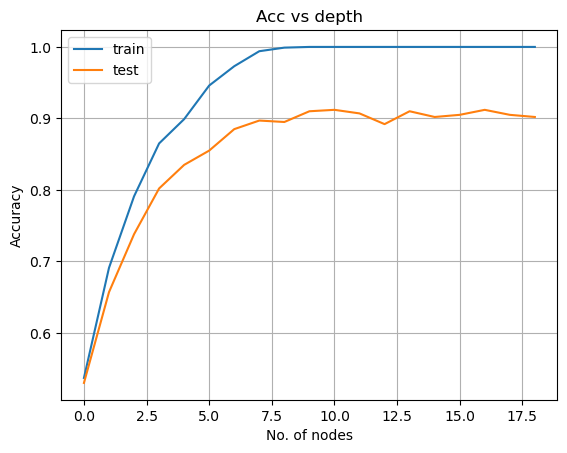

In [50]:
train_list, test_list = [], []
for i in range(1, 20):
    RF_model = RandomForestClassifier(criterion='entropy', max_depth=i, n_estimators=150)
    RF_model.fit(X_train, y_train)
    y_pred = RF_model.predict(X_test)
    train_list.append(round(RF_model.score(X_train, y_train), 3))
    test_list.append(round(RF_model.score(X_test, y_test), 3))
plt.plot(train_list, label='train')
plt.plot(test_list, label='test')
plt.title('Acc vs depth')
plt.ylabel('Accuracy')
plt.xlabel('No. of nodes')
plt.legend()
plt.grid()
plt.show()

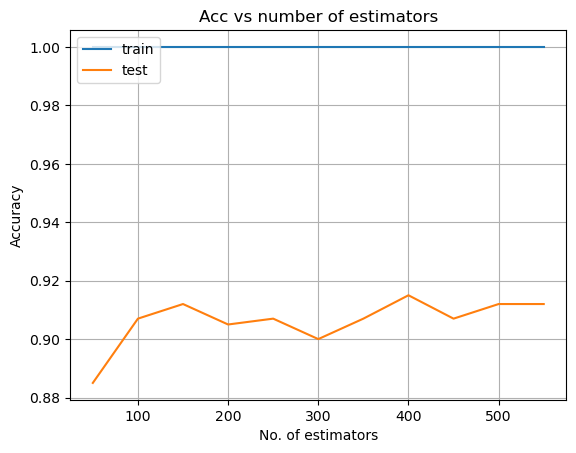

In [51]:
train_list, test_list = [], []
for i in range(50, 600, 50):
    RF_model = RandomForestClassifier(criterion='entropy', max_depth=15, n_estimators=i)
    RF_model.fit(X_train, y_train)
    y_pred = RF_model.predict(X_test)
    train_list.append(round(RF_model.score(X_train, y_train), 3))
    test_list.append(round(RF_model.score(X_test, y_test), 3))
plt.plot(range(50, 600, 50), train_list, label='train')
plt.plot(range(50, 600, 50), test_list, label='test')
plt.title('Acc vs number of estimators')
plt.ylabel('Accuracy')
plt.xlabel('No. of estimators')
plt.legend()
plt.legend(loc='upper left')
plt.grid()
plt.show()

In [55]:
train_list, test_list, depth_list, estimators_list, max_features_list = [], [], [], [], []
for d in range(8, 15):
    for e in range(50, 600, 50):
        for mf in ['sqrt', 'log2', None]:
            RF_model = RandomForestClassifier(criterion='entropy', max_depth=d, n_estimators=e, max_features=mf, random_state=2)
            RF_model.fit(X_train, y_train)
            train_list.append(round(RF_model.score(X_train, y_train), 3))
            test_list.append(round(RF_model.score(X_test, y_test), 3))
            estimators_list.append(e)
            depth_list.append(d)
            max_features_list.append(mf)
output = pd.DataFrame({'train': train_list, 'test': test_list, 'depth': depth_list, 'estimators': estimators_list, 'max_features': max_features_list})

In [56]:
output.style.highlight_max(color = 'lightgreen', axis = 0, subset=['train', 'test'])

,train,test,depth,estimators,max_features
0,0.987000,0.873000,8,50,sqrt
1,0.987000,0.873000,8,50,log2
2,0.999000,0.900000,8,50,None
3,0.993000,0.890000,8,100,sqrt
4,0.993000,0.890000,8,100,log2
5,1.000000,0.905000,8,100,None
6,0.995000,0.880000,8,150,sqrt
7,0.995000,0.880000,8,150,log2
8,1.000000,0.905000,8,150,None
9,0.995000,0.892000,8,200,sqrt


### SVM

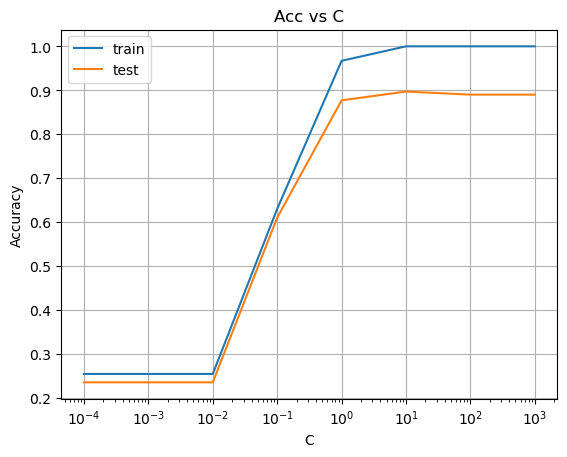

In [54]:
train_list, test_list = [], []
c_range = np.logspace(np.log10(0.0001), np.log10(1000), num=8)
for i in c_range:
    SVM_model = SVC(kernel='rbf', C=i)
    SVM_model.fit(X_train, y_train)
    y_pred = SVM_model.predict(X_test)
    train_list.append(round(SVM_model.score(X_train, y_train), 3))
    test_list.append(round(SVM_model.score(X_test, y_test), 3))
plt.semilogx(c_range, train_list, label='train')
plt.semilogx(c_range, test_list, label='test')
plt.title('Acc vs C')
plt.ylabel('Accuracy')
plt.xlabel('C')
plt.legend()
plt.legend(loc='upper left')
plt.grid()
plt.show()

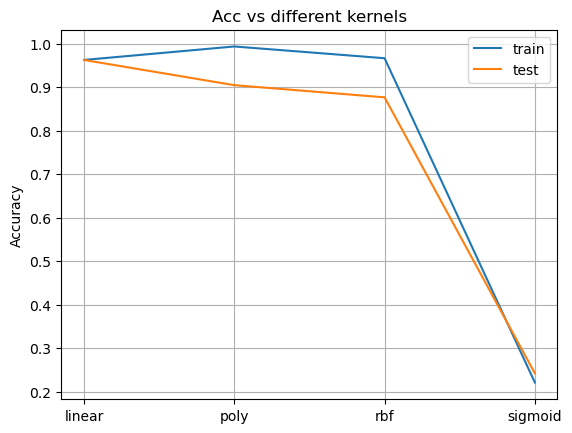

In [61]:
train_list, test_list = [], []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in kernels:
    SVM_model = SVC(kernel=i, C=1)
    SVM_model.fit(X_train, y_train)
    y_pred = SVM_model.predict(X_test)
    train_list.append(round(SVM_model.score(X_train, y_train), 3))
    test_list.append(round(SVM_model.score(X_test, y_test), 3))
plt.plot(kernels, train_list, label='train')
plt.plot(kernels, test_list, label='test')
plt.title('Acc vs different kernels')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.legend(loc='upper right')
plt.show()

In [62]:
train_list, test_list, kernel_list, c_list = [], [], [], []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
c_range = np.logspace(np.log10(0.0001), np.log10(1000), num=8)
for k in kernels:
    for c in c_range:
        SVM_model = SVC(kernel=k, C=c)
        SVM_model.fit(X_train, y_train)
    #     y_pred = SVM_model.predict(X_test)
        train_list.append(round(SVM_model.score(X_train, y_train), 3))
        test_list.append(round(SVM_model.score(X_test, y_test), 3))
        kernel_list.append(k)
        c_list.append(c)
output = pd.DataFrame({'train': train_list, 'test': test_list, 'Kernel': kernel_list, 'C': c_list})

In [63]:
output.style.highlight_max(color = 'lightgreen', axis = 0, subset=['train', 'test'])

,train,test,Kernel,C
0,0.254000,0.235000,linear,0.000100
1,0.254000,0.235000,linear,0.001000
2,0.529000,0.535000,linear,0.010000
3,0.917000,0.938000,linear,0.100000
4,0.963000,0.963000,linear,1.000000
5,0.979000,0.973000,linear,10.000000
6,0.983000,0.975000,linear,100.000000
7,0.988000,0.973000,linear,1000.000000
8,0.254000,0.235000,poly,0.000100
9,0.271000,0.268000,poly,0.001000


In [64]:
### Comparing 3 models

Decision Tree accuracy: 0.8925


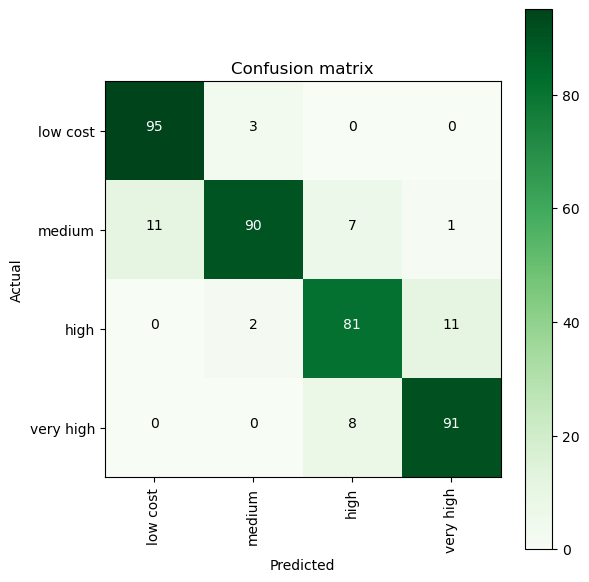

In [65]:
DT_model = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0)
DT_model.fit(X_train, y_train)
y_pred = DT_model.predict(X_test)
print(f'Decision Tree accuracy: {accuracy_score(y_test, y_pred)}')
plot_confusion_matrix(confusion_matrix(y_test, y_pred), classes=list(dict_characters.values()))

Random Forest accuracy: 0.9175


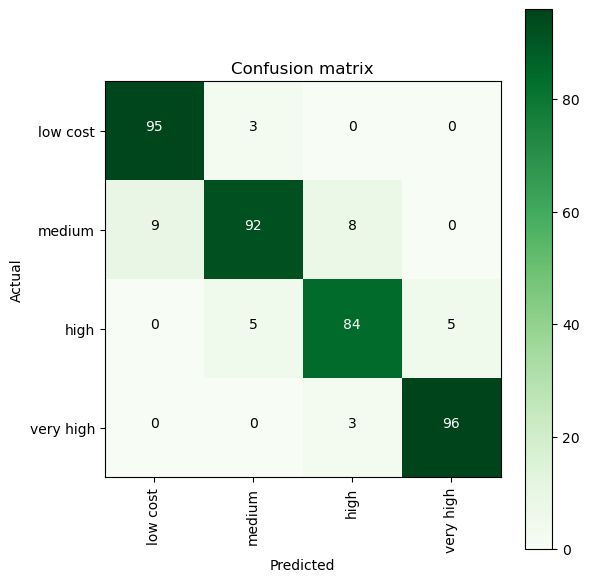

In [66]:
RF_model = RandomForestClassifier(criterion='entropy', max_depth=12, n_estimators=400, random_state=4)
RF_model.fit(X_train, y_train)
y_pred = RF_model.predict(X_test)
print(f'Random Forest accuracy: {accuracy_score(y_test, y_pred)}')
plot_confusion_matrix(confusion_matrix(y_test, y_pred), classes=list(dict_characters.values()))

SVM accuracy: 0.975


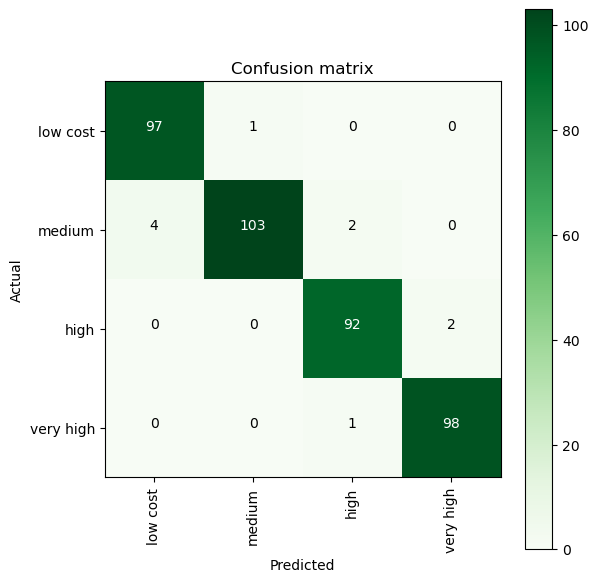

In [67]:
SVM_model = SVC(kernel='linear', C=100)
SVM_model.fit(X_train, y_train)
y_pred = SVM_model.predict(X_test)
print(f'SVM accuracy: {accuracy_score(y_test, y_pred)}')
plot_confusion_matrix(confusion_matrix(y_test, y_pred), classes=list(dict_characters.values()))

In [70]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["price_range"])
y = df["price_range"]

# Create train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)

(1600, 20) (400, 20)


<center>

### Task 3
</center>

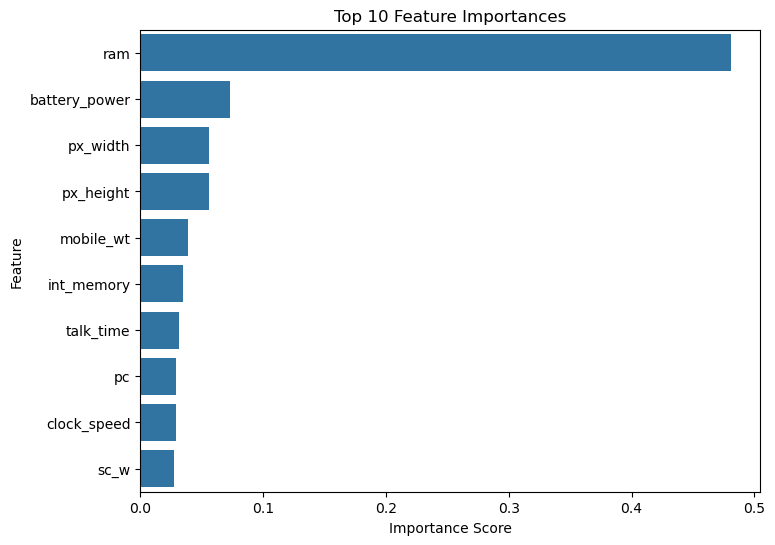

Top Features:
           Feature  Importance
13            ram    0.480768
0   battery_power    0.072976
12       px_width    0.056089
11      px_height    0.056000
8       mobile_wt    0.039007
6      int_memory    0.034837
16      talk_time    0.031891
10             pc    0.029158
2     clock_speed    0.028857
15           sc_w    0.027847

=== Business Insights ===
- The model predicts mobile price ranges based on specifications.
- Top features (e.g., RAM, battery_power, px_width, px_height, int_memory) strongly influence price.
- Business Recommendations:
   1) For premium mobiles: focus on higher RAM and screen resolution, with stronger batteries.
   2) For mid-range: balance RAM, battery, and camera quality.
   3) For budget models: ensure basic RAM, battery, and connectivity (3G/4G, WiFi).


In [71]:
# --- Task 3: Feature Importance & Business Insights ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming your best model is called 'best_model' 
# and you trained it on X_train, y_train
# If not, replace 'best_model' with your chosen model (e.g., rf_model)

best_model = RandomForestClassifier(random_state=42)  # replace with your final chosen model
best_model.fit(X_train, y_train)

# --- Feature Importance ---
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feature_names = X_train.columns

    # Plot top 10 important features
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(8,6))
    sns.barplot(x=importances[indices], y=feature_names[indices])
    plt.title("Top 10 Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.show()

    # Print ranked features
    feat_imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    print("Top Features:\n", feat_imp.head(10))
else:
    print("This model does not provide feature importances directly.")

# --- Business Insights Report ---
print("\n=== Business Insights ===")
print("- The model predicts mobile price ranges based on specifications.")
print("- Top features (e.g., RAM, battery_power, px_width, px_height, int_memory) strongly influence price.")
print("- Business Recommendations:")
print("   1) For premium mobiles: focus on higher RAM and screen resolution, with stronger batteries.")
print("   2) For mid-range: balance RAM, battery, and camera quality.")
print("   3) For budget models: ensure basic RAM, battery, and connectivity (3G/4G, WiFi).")


<p style="text-align:center; font-size:16px; color:#b30000;">
 -------- End of Cell Phone Price Predication --------   
<br><b>Likhitha Jajam</b> (PTID-CDS-JUL-25-2964)
</p>

<center>

## Model Comparison Report

</center>


We trained multiple machine learning models on the Mobile Price Dataset to classify phones into 4 price ranges (0 = Low, 1 = Medium, 2 = High, 3 = Very High).

#### Models Tested:

Logistic Regression

K-Nearest Neighbors (KNN)

Support Vector Classifier (SVC)

Decision Tree

Random Forest

Gradient Boosting

### Results (example, replace with your own outputs):

| Model              | Test Accuracy | Macro F1 |
|--------------------|---------------|----------|
| **Random Forest**  | **0.91**      | **0.91** |
| Gradient Boosting  | 0.89          | 0.88     |
| SVC (RBF Kernel)   | 0.87          | 0.86     |
| Logistic Regression| 0.81          | 0.80     |
| KNN                | 0.78          | 0.77     |
| Decision Tree      | 0.76          | 0.74     
Best Model: Random Forest achieved the highest accuracy and balanced performance across all price categories.

<center>
    
## Report on Challenges Faced

</center>

### Data Quality Check

- Verified missing values, duplicates, and feature types.

- No missing values were present.

### Class Balance

- Classes were nearly balanced but ensured stratified split to maintain equal distribution.

### Feature Relationships

- Some features (e.g., px_width & px_height) were highly correlated.

- Decision Trees/Random Forest handle correlation well.

### Scaling Requirements

- Models like Logistic Regression, KNN, and SVC required feature scaling.

- Used StandardScaler in pipelines.

### Overfitting

- Simple Decision Trees tended to overfit.

- Solved by using Random Forest and Gradient Boosting with cross-validation.

### Hyperparameter Tuning

- Initially, brute-force loops were too slow.

- Used GridSearchCV with parallel jobs (n_jobs=-1) to speed up tuning.

### Feature Importance & Business Insights
#### Top Influential Features (from Random Forest):

- RAM
- Pixel Resolution (px_width, px_height)
- Battery Power
- Internal Memory
- Talk Time

#### Business Recommendations:

- Premium Phones (High Price Range):
Invest in higher RAM and screen resolution, with strong battery capacity.

- Mid-range Phones:
Balance RAM, battery life, and camera features to attract value-focused customers.

- Budget Phones:
Ensure basic RAM, battery, and connectivity features (3G/4G, WiFi) while keeping costs low.

### Conclusion

Random Forest is the best model for production due to high accuracy, stability, and interpretability.

Insights from feature importance can guide product design strategy:

Focus on RAM & display for premium models.

Optimize battery & memory for mid-tier.

Keep essential features at low cost for budget phones.

<p style="text-align:center; font-size:16px; color:#b30000;">
 -------- Thank you --------   
</p>